## About This notebook: 

This notebook serves to explore different preprocessing and postprocessing steps with spikeInterface. 

What you need to use this notebook: 
- Input data: .dat and .xml files for a single probe, xc and yc information

***

Load data into the proper format for SpikeInterface

Create a probe for the data and match the two 

Show general stats / visualize the data quickly 

identify any regions that are extremely noisy (example beginning of buszaki data) maybe make a function that will identify these regions and gives the start and end time of these (or index) 

other than those already marked as problematic from the XML file, identify which other channels are noise (ie, waves or other type of noise (figure out what types of noise there are))

Preprocess (give possibility to explore different functions and to give stats on which is best / add any functions that could be useful given our particular data (ie not knowing the x-coord with certainty))

spike sorting, have access to different algorithms and give benchmarking results on which are good and which are less good / why 
- determine a metric 

convert data into NWB format / output to phy ? 

***
### Loading data

In [3]:
import spikeinterface as si 
from dataLoading_utils import getXMLData
from dataAnalysis_utils import find_repetitive_channels
import numpy as np
import spikeinterface.widgets as sw
import matplotlib.pyplot as plt
from probeinterface import Probe, ProbeGroup, generate_linear_probe, generate_multi_shank, combine_probes 
from probeinterface.plotting import plot_probe

In [ ]:
# OPTIONAL: See data loading
# - modifying the xml 'skip' parameter based on impedance excel 

Current questions: 
- distances between contact sites for our flexible electrodes are not constant
- probes are not inserted vertically so they have a z component as well, does this make a difference
- the xc are all identical as we assume contact sites to be about stacked on the vertical axis. is this a valid assumption 

In [2]:
buzsaki_data = {
    "dat_path": r"D:\Yanik Lab Dropbox\Peter Gombkoto\Multiarea rat recordings\Buzsaki\RAT\ETH_F_R01_20260311\homecage_260311_144123\amplifier.dat",
    "xml_path": r"D:\Yanik Lab Dropbox\Peter Gombkoto\Multiarea rat recordings\Buzsaki\RAT\ETH_F_R01_20260311\homecage_260311_144123\amplifier.xml",
    "xc_dist": [0,1000],       # x-axis distance between contact sites in um (0.0 if all contact sites are aligned vertically)
    "yc_dist": [15.5, 50.0],      # y-axisdistance between contact sites in um 
}

neuroTech_data = {
    "dat_path": r"D:\Yanik Lab Dropbox\Peter Gombkoto\Multiarea rat recordings\rTBY34\preprocessed_data\5_freely_behav_220311_151222\amplifier.dat",
    "xml_path": r"D:\Yanik Lab Dropbox\Peter Gombkoto\Multiarea rat recordings\rTBY34\preprocessed_data\5_freely_behav_220311_151222\amplifier.xml",
    "xc_dist": [0, 1000, 2000, 3000],       # x-axis distance between contact sites in um (0.0 if all contact sites are aligned vertically)
    "yc_dist": [60.0, 40.0, 40.0, 60.0],      # y-axisdistance between contact sites in um 
}


# TODO: Modify the code below for your particular input data
data = buzsaki_data

dat_path = data["dat_path"]
xml_path = data["xml_path"]
xc_dist = data["xc_dist"]
yc_dist = data["yc_dist"]

### Create a recording object 

In [ ]:
channel_ids, xml_data = getXMLData(xml_path)
nBits, nChannels, samplingRate, offset, lfpSamplingRate = xml_data
uV_per_count = 0.195 #https://intantech.com/files/Intan_RHX_user_guide.pdf

recording = si.read_binary(file_paths=dat_path, sampling_frequency=samplingRate, dtype=f"int{nBits}", num_channels=nChannels, channel_ids=channel_ids, is_filtered=False)
recording

In [ ]:
shank1_traces = recording.get_traces(channel_ids=channel_ids[:64], start_frame=1200000, end_frame=2400000)  # Get the first second of data for the first 64 channels

t = np.arange(shank1_traces.shape[0]) / (samplingRate) # Time vector in seconds

[]

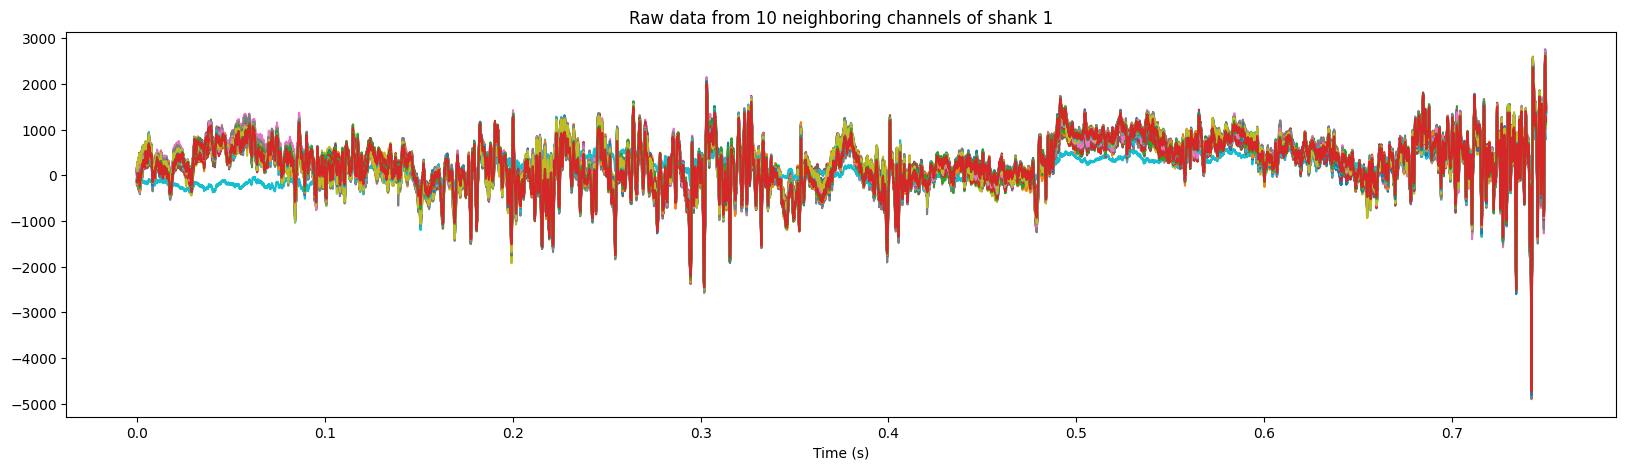

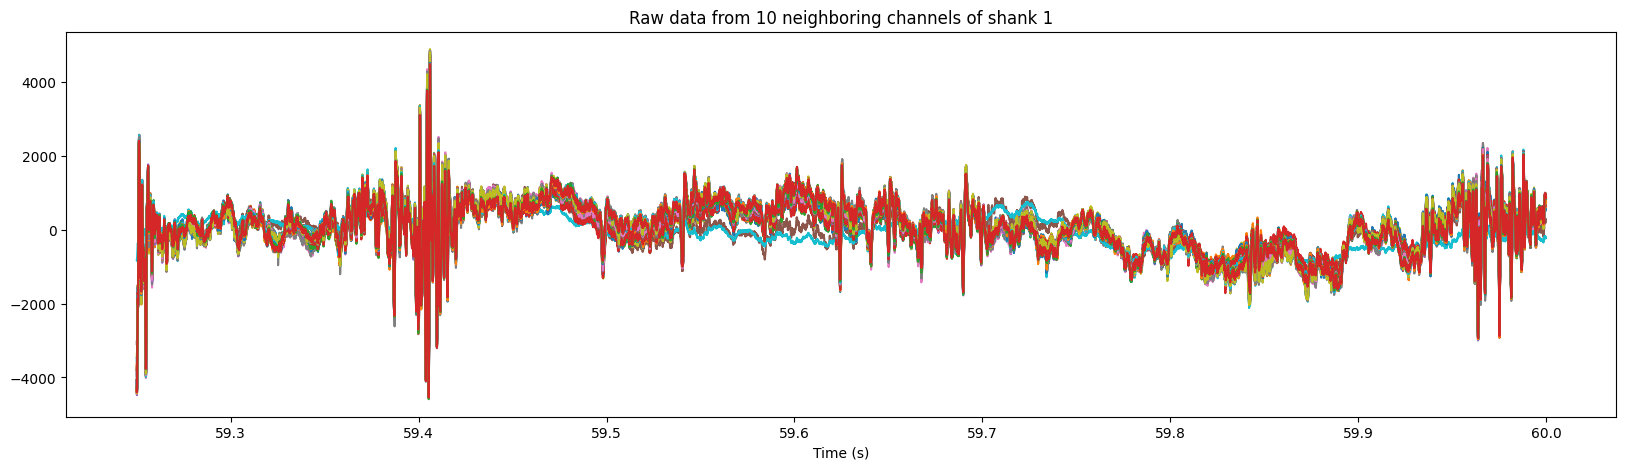

In [ ]:
# plot sample channels to get an idea of what the data looks like 

plt.figure(figsize=(20, 5))
plt.plot(t[:15000], shank1_traces[:15000])  
plt.title("Raw data from 10 neighboring channels of shank 1")
plt.xlabel("Time (s)")
plt.plot()
plt.figure(figsize=(20, 5))
plt.plot(t[-15000:], shank1_traces[-15000:])  
plt.title("Raw data from 10 neighboring channels of shank 1")
plt.xlabel("Time (s)")
plt.plot()

### Create a probe object

For now, we assume the probe to be fixed and linear

- `set_contact_ids`: metadata 
- `set_device_channel_indices`: hardware mapping

In [ ]:
# generate multiple individual linear shanks and combine them into a multi-shank probe
shank1 = generate_linear_probe(num_elec = 64, ypitch = 15.5, contact_shapes="square", contact_shape_params={"width": 13})
shank1.set_device_channel_indices(channel_ids[:64]) # set the channel ids for the first shank
shank2 = generate_linear_probe(num_elec = 64, ypitch = 50.0, contact_shapes="square", contact_shape_params={"width": 13})
shank2.set_device_channel_indices(channel_ids[64:]) # set the channel ids for the second shank
shank2.set_cont
# define the x-axis position of the shanks
shank2.move([3000, 0])

multiShank_probe = combine_probes([shank1, shank2])

recording.set_probe(multiShank_probe)

NameError: name 'channel_ids' is not defined

In [ ]:
plot_probe(multiShank_probe)

***

### Preprocessing

Beware of which steps do and do not use the probe geometry. 

Geometry agnostic: bandpass_filter, highpass_filter, notch_filter, generic filter, center, zscore, scale, clip, astype, resample, rectify, phase_shift, whiten

Geometry-dependent: CAR, average_across_direction, directional_derivative, highpass_spatial_filter, depth_order, compute_motion, correction_motion, 

In [ ]:
spikeinterface.preprocessing.average_across_direction(parent_recording: BaseRecording, direction: str = 'y', dtype='float32')
spikeinterface.preprocessing.bandpass_filter(recording, freq_min=300.0, freq_max=6000.0, margin_ms='auto', dtype=None, ignore_low_freq_error=False, _skip_margin_warning_for_old_version=False, **filter_kwargs)
spikeinterface.preprocessing.center(recording, mode='median', dtype='float32', **random_chunk_kwargs)
spikeinterface.preprocessing.common_reference(recording: BaseRecording, reference: Literal['global', 'single', 'local'] = 'global', operator: Literal['median', 'average'] = 'median', groups: list | None = None, ref_channel_ids: list | str | int | None = None, local_radius: tuple[float, float] = (30.0, 55.0), min_local_neighbors: int = 5, dtype: str | dtype | None = None)
spikeinterface.preprocessing.compute_motion(recording: BaseRecording, preset: Literal['dredge', 'medicine', 'dredge_fast', 'nonrigid_accurate', 'nonrigid_fast_and_accurate', 'rigid_fast', 'kilosort_like'] = 'dredge_fast', detect_kwargs: dict = {}, select_kwargs: dict = {}, localize_peaks_kwargs: dict = {}, estimate_motion_kwargs: dict = {}, output_motion_info: bool = False, folder: str | Path | None = None, overwrite: bool = False, raise_error: bool = True, **job_kwargs)→ dict

spikeinterface.preprocessing.correct_motion(recording: BaseRecording, preset: Literal['dredge', 'medicine', 'dredge_fast', 'nonrigid_accurate', 'nonrigid_fast_and_accurate', 'rigid_fast', 'kilosort_like'] = 'dredge_fast', folder: str | Path | None = None, output_motion: bool = False, output_motion_info: bool = False, overwrite: bool = False, detect_kwargs: dict = {}, select_kwargs: dict = {}, localize_peaks_kwargs: dict = {}, estimate_motion_kwargs: dict = {}, interpolate_motion_kwargs: dict = {}, **job_kwargs)
spikeinterface.preprocessing.detect_bad_channels(recording: BaseRecording, method: str = 'coherence+psd', std_mad_threshold: float = 5, psd_hf_threshold: float = 0.02, dead_channel_threshold: float = -0.5, noisy_channel_threshold: float = 1.0, outside_channel_threshold: float = -0.75, outside_channels_location: Literal['top', 'bottom', 'both'] = 'top', n_neighbors: int = 11, nyquist_threshold: float = 0.8, direction: Literal['x', 'y', 'z'] = 'y', chunk_duration_s: float = 0.3, num_random_chunks: int = 100, welch_window_ms: float = 10.0, highpass_filter_cutoff: float = 300, neighborhood_r2_threshold: float = 0.9, neighborhood_r2_radius_um: float = 30.0, seed: int | None = None, channel_filters: set | None = None)

spikeinterface.preprocessing.detect_artifact_periods(recording: BaseRecording, method: Literal['envelope', 'saturation'] = 'envelope', method_kwargs: dict | None = None, job_kwargs: dict | None = None)→ ndarray
spikeinterface.preprocessing.filter(recording, band=(300.0, 6000.0), btype='bandpass', filter_order=5, ftype='butter', filter_mode='sos', margin_ms=None, add_reflect_padding=False, coeff=None, dtype=None, direction='forward-backward')
spikeinterface.preprocessing.whiten(recording, dtype=None, apply_mean=False, regularize=False, regularize_kwargs=None, mode='global', radius_um=100.0, int_scale=None, eps=None, W=None, M=None, **random_chunk_kwargs)

***

In [ ]:
w_ts = sw.plot_traces(recording, channel_ids=channel_ids[:10])

**consider using the read_binary_folder function to concatinate multiple sessions together